#### Import Dati

In [ ]:
import pandas as pd
import numpy as np
import re
import math
import os
import joblib


In [ ]:
pd.options.display.max_columns = 999
pd.options.display.max_rows = 999

In [ ]:
import sklearn.model_selection  as skl_msel
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import sklearn.metrics  as skl_metr


In [ ]:
data_dir = os.path.join("..", "data")
df = pd.read_parquet(os.path.join(data_dir,'df_def.parquet'))

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 76 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   giorno                             2087 non-null   datetime64[ms]
 1   PM10                               2087 non-null   float64       
 2   media_NO2                          2087 non-null   float64       
 3   mediana_NO2                        2087 non-null   float64       
 4   massimo_NO2                        2087 non-null   float64       
 5   flag_PM25_missing                  1396 non-null   object        
 6   flag_PM25_SF                       691 non-null    object        
 7   flag_O3_missing                    1382 non-null   object        
 8   flag_O3_VC                         691 non-null    object        
 9   flag_O3_interpol                   691 non-null    object        
 10  mese_giorno                        2087 non-nul

In [ ]:
list_var = ['precipitation_sum',
                    'cloud_cover_max',
                    'wind_speed_10m_min',
                    'wind_gusts_10m_max',
                    'pressure_msl_max',
                    'soil_moisture_28_to_100cm_mean',
                    'dew_point_2m_max',
                    'temperature_2m_max',
                    'shortwave_radiation_sum'
                     ]

In [ ]:
# split direttamente sul dataframe
xtr, xte, ytr, yte = skl_msel.train_test_split(
    df,
    df['target_pm10'],
    test_size=0.30,
    random_state=33
)

# flag basati sull'index
df['flag train'] = df.index.isin(xtr.index)
df['flag test'] = df.index.isin(xte.index)

#### Modello

In [ ]:
params = {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 700}

In [ ]:
from xgboost import XGBClassifier

# calcolo peso per class imbalance
n_neg = (df['target_pm10'] == 0).sum()
n_pos = (df['target_pm10'] == 1).sum()
scale_pos_weight = n_neg / n_pos

cla_xgb = XGBClassifier(
    **params,
    scale_pos_weight=scale_pos_weight
)

cla_xgb.fit(
    df.loc[df['flag train'], list_var].values,
    df.loc[df['flag train'], 'target_pm10'].values
)

# probabilità della classe 1
df['proba (xgb)'] = cla_xgb.predict_proba(
    df.loc[:, list_var].values
)[:, 1]

df['prediction (xgb)'] = (df['proba (xgb)'] > 0.3).astype(int)

#### Precision

In [ ]:
pre_xgb = skl_metr.precision_score(df.loc[df['flag test'], 'target_pm10'] == 1,
                                    df.loc[df['flag test'], 'prediction (xgb)'] == 1)

print(f'Model precision (decision xgb): {pre_xgb:.2}')

Model precision (decision xgb): 0.71


#### Recall

In [ ]:
rec_xgb = skl_metr.recall_score(df.loc[df['flag test'], 'target_pm10'] == 1,
                                 df.loc[df['flag test'], 'prediction (xgb)'] == 1)

print(f'Model recall (xgb): {rec_xgb:.2}')

Model recall (xgb): 0.91


#### Table

In [ ]:
df_pivot = pd.pivot_table(df.loc[df['flag test'], :],
                          index='target_pm10', columns='prediction (xgb)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (xgb),0,1
target_pm10,,
0,583,12
1,3,29


In [ ]:
import sklearn.metrics as skl_metr

df_test = df.loc[df['flag test']]

y_true = df_test['target_pm10']

models = {
    "xgb": "prediction (xgb)"
}

results = []

for name, col in models.items():
    y_pred = df_test[col]

    results.append({
        "Model": name,
        "Accuracy": skl_metr.accuracy_score(y_true, y_pred),
        "Precision": skl_metr.precision_score(y_true, y_pred),
        "Recall": skl_metr.recall_score(y_true, y_pred),
        "F1-score": skl_metr.f1_score(y_true, y_pred),
        "MCC": skl_metr.matthews_corrcoef(y_true, y_pred)
    })

df_results = pd.DataFrame(results)

df_results = df_results.round(4)
df_results

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,xgb,0.9761,0.7073,0.9062,0.7945,0.7888


Abbiamo scelto un modello con alta recall perchè
https://www.airc.it/cancro/prevenzione-tumore/prevenzione-per-tutti/inquinamento-atmosferico-prevenzione-dei-rischi-per-la-salute 

## Feature importance

c:\Users\Boom\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 99%|===================| 2067/2087 [00:29<00:00]        

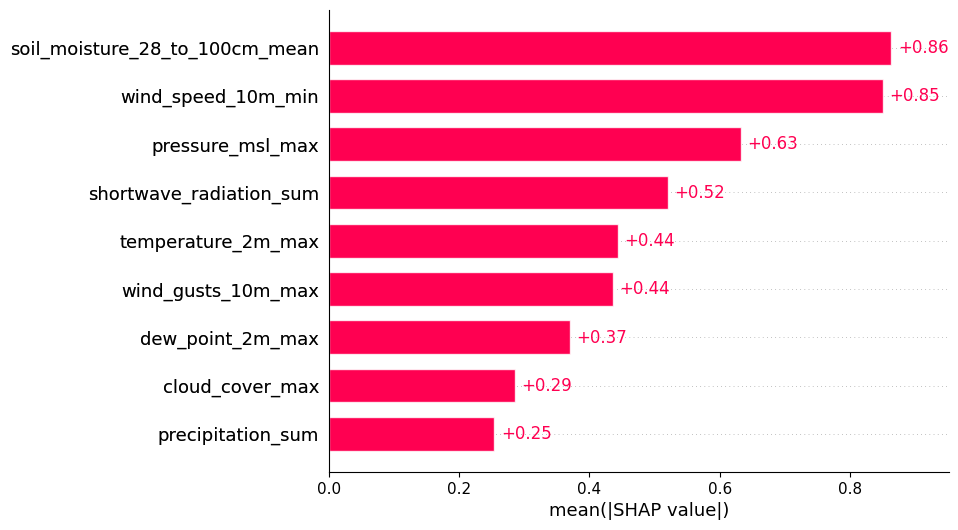

In [ ]:
modello = cla_xgb.fit(
    df.loc[df['flag train'], list_var].values,
    df.loc[df['flag train'], 'target_pm10'].values
)

import shap

# feature matrix e target
X = df[list_var]
y = df["target_pm10"]

# background (campione del dataset)
background = X.sample(100, random_state=42)

# SHAP explainer
explainer = shap.Explainer(modello, background)

# calcolo valori SHAP
shap_values = explainer(X)

# plot importanza globale
shap.plots.bar(shap_values)

Mostra l’importanza basata sul massimo effetto assoluto: prende il caso più estremo

Dice quali variabili possono avere effetti fortissimi anche se rari

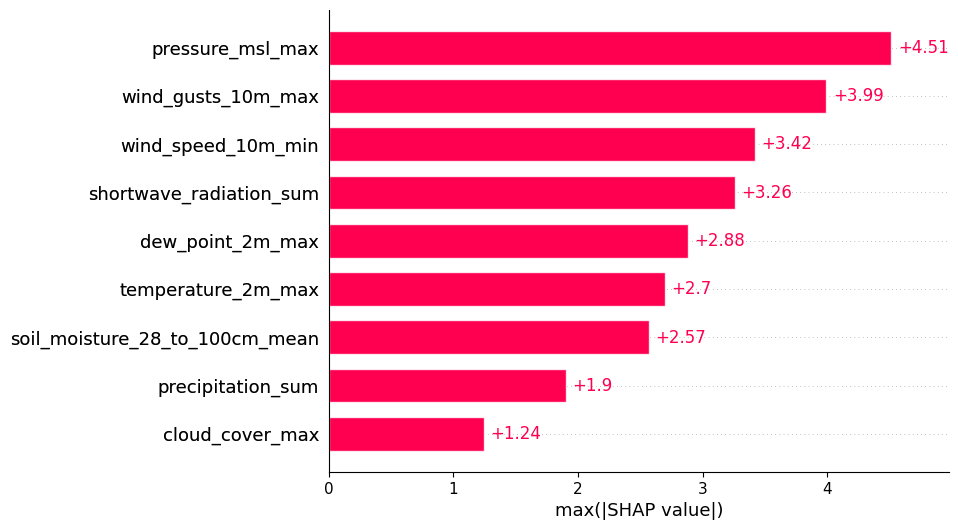

In [ ]:
shap.plots.bar(shap_values.abs.max(0))

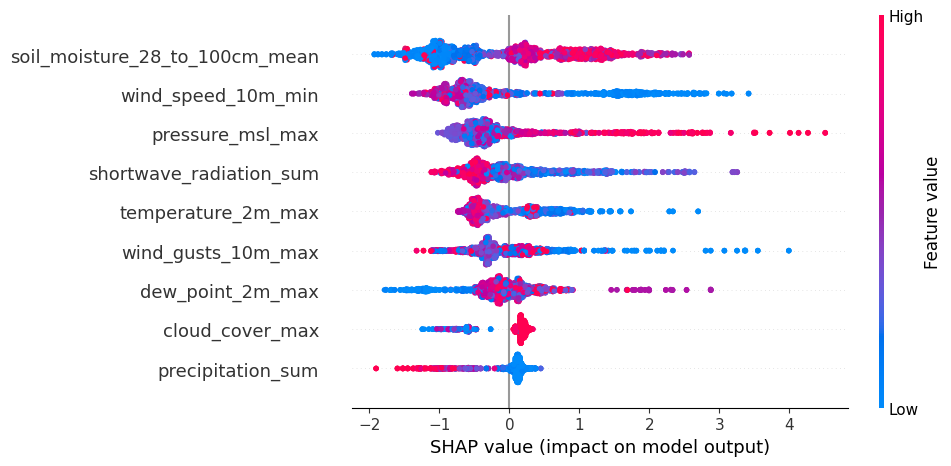

In [ ]:
shap.plots.beeswarm(shap_values)

## Salvo il modello

In [ ]:
model_path = os.path.join("..", "data", "xgb_model.pkl")

joblib.dump(cla_xgb, model_path)

['..\\data\\xgb_model.pkl']